# COSC2671: Social Media and network Analysis  

## Assignment 1 : Analysing and Tracking the Sentiment and Topics on Social Media

Author: Syeda Shabnam Khan (s4020189)


### Data Extraction

We are using the script with reddit client function provided in the workshop to pass our password client id, secret and user name. The magic functions to automatically reload redit client information so that changes in the redditClient.py is reflected in the markdown.

In [7]:
%load_ext autoreload
%autoreload 1
%aimport redditClient

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Importing reditClient script and redit api praw.

In [6]:
from redditClient import redditClient
import praw

Setting the subreddit of our topic and limit for our data request. We want to extract maximum number of posts the redit client allows us. Therefore, we have set our hot limit to 1000.

In [ ]:
# subreddit name we interested in getting the hot submissions
sSubredditName = 'GooglePixel'
# maximum number of hot submissions
hotLimit = 1000

In [ ]:
# construct Reddit client
client = redditClient()

# sanity check, printing our username
print(client.user.me())

In [ ]:
# specify which subreddit we are interested in
subreddit = client.subreddit(sSubredditName)

In [ ]:
from datetime import datetime
import csv

# we are iterating over redit posts and extracting
# title, description, post time, score and comment count
# saving the data into a csv file for analysis

filename = 'reddit_posts_new.csv'

with open(filename, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Title', 'Description', 'Post_time', 'Score', 'Comment_count'])

    # print out the hot submisisons
    for submission in subreddit.hot(limit=hotLimit):
    # print title, but we can print other information as well
        title =submission.title
        description =submission.selftext
        post_time =datetime.fromtimestamp(submission.created_utc).strftime('%Y-%m-%d %H:%M:%S')
        score = submission.score
        comment_count = submission.num_comments

        writer.writerow([title, description, post_time, score, comment_count])

# to indicate completion of data extraction
print('done!')

### Data cleaning and exploration

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import regex as re
from itertools import chain

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.util import ngrams
from nltk.stem import WordNetLemmatizer
# nltk.download("wordnet")
# nltk.download("omw-1.4")
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
# nltk.download('vader_lexicon')

import math
import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Accessing post from csv file
filename = 'reddit_posts.csv'
df= pd.read_csv(filename)
df.head()

,Title,Description,Post_time,Score,Comment_count
0,The September 2024 Superthread: Battery; Order...,*If you were redirected here from a removed po...,2024-09-01 20:00:29,3,16
1,Pixel 9 Series Shipping Megathread - September,Please post all shipping related content here!,2024-09-01 23:26:08,20,154
2,Flossy Carter - Google Pixel 9 Pro Xl - “Real ...,NaN,2024-09-03 11:37:51,64,54
3,How have I never noticed this brilliant Pixel ...,I'm not new to Google phones as I've been usin...,2024-09-03 04:57:48,205,77
4,Fingerprint sensor on the 9 series is actually...,"I was worried about this before buying it, but...",2024-09-03 07:07:33,88,55


In [3]:
print(df.shape)
print(df.info())

(937, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title          937 non-null    object
 1   Description    923 non-null    object
 2   Post_time      937 non-null    object
 3   Score          937 non-null    int64 
 4   Comment_count  937 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 36.7+ KB
None


In [4]:
# Taking a quick full view of the contents in descriotion and title
# defining a print function
def quick_view(row = 0, clean =0):
   
    print(f"title: \n{df['Title'][row]}\n")
    print(f"description: \n{df['Description'][row]}")
    print('_'*30)

for r in range(6):
    quick_view(r)


title: 
The September 2024 Superthread: Battery; Orders; Which Pixel?; and More

description: 
*If you were redirected here from a removed post or a Megathread link, please scroll down.*

This is the Superthread, the subreddit's collection of Megathreads and other useful links.

Here are the Megathreads:

* **To open to the weekly Photos Megathread**, [search for the latest thread here](https://www.reddit.com/r/GooglePixel/search/?q=%22Photos%20Megathread%22%20author%3AGooglePixelMods&restrict_sr=1&sort=new). You can also share your photos on r/pixelography.
* **To open to "Which Pixel should I buy?" Megathread**, [search for the latest thread here](https://www.reddit.com/r/GooglePixel/search/?q="Which%20Pixel"%20author%3AGooglePixelMods&restrict_sr=1&sort=new).
* **To open the Shipping Megathread**, home of order-related comments, issues, and suggestions, [follow this link](https://reddit.com/r/GooglePixel/comments/185kvy9/madebygoogle_2023_holiday_shipping_megathread/).
* **To access

From the quick view we can see that the first entry is just some list of links with no relevant incormation for us. There are also instances with title only, i.e., no description. Moreover, there are links to images. It is safe to assume that other posts will have links to images, videos and external sites.

In [5]:
# drop row 0 and replace index
# look for null values
df=df.drop(0)
df.reset_index(drop=True, inplace=True)
df.head()

,Title,Description,Post_time,Score,Comment_count
0,Pixel 9 Series Shipping Megathread - September,Please post all shipping related content here!,2024-09-01 23:26:08,20,154
1,Flossy Carter - Google Pixel 9 Pro Xl - “Real ...,NaN,2024-09-03 11:37:51,64,54
2,How have I never noticed this brilliant Pixel ...,I'm not new to Google phones as I've been usin...,2024-09-03 04:57:48,205,77
3,Fingerprint sensor on the 9 series is actually...,"I was worried about this before buying it, but...",2024-09-03 07:07:33,88,55
4,Y'all try the add me feat with yourself?,https://imgur.com/a/3uew78J,2024-09-03 07:58:48,30,14


In [6]:
print('shape: ', df.shape)
print(df.isna().sum())

shape:  (936, 5)
Title             0
Description      14
Post_time         0
Score             0
Comment_count     0
dtype: int64


In [7]:
def clean_text(text):
    # this function cleans urls punctuations, 
    # normalize case and remove extra spaces
    # replacing the nan with empty string
    if isinstance(text, str):
        
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = text.lower().strip()

    return text


In [8]:
# clean title and description columns
df['Title']=df['Title'].apply(clean_text)
df['Description'] = df['Description'].apply(clean_text)

In [9]:
# Create a column Full_Post that holds title and description together
df['Full_Post'] = df['Title'].fillna('') + ' ' + df['Description'].fillna('')

print(df['Full_Post'][2])

how have i never noticed this brilliant pixel camera feature before im not new to google phones as ive been using them exclusively for close to a decade but somehow i missed this amazing feature until today

when youre filming a video the frontback camera switcher button transforms into a camera shutter button this lets you take still photos at the same time that you are filming the video

this is a game changer for me as there are many times ive wanted to take both pictures and video like during the last solar eclipse how long has this feature been around i cant believe ive never seen it before


### Tokenize

We tokenize the full post, remove stopwords and lematize.

In [10]:
# define a function to tokenize and remove stop words
def tokenize_filter_stopwords(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))

    f_tokens = [word for word in tokens if word not in stop_words]
    return f_tokens

In [11]:
# tokenize and remove stopwords
df['Tokens'] = df['Full_Post'].apply(tokenize_filter_stopwords)
df.head()

,Title,Description,Post_time,Score,Comment_count,Full_Post,Tokens
0,pixel 9 series shipping megathread september,please post all shipping related content here,2024-09-01 23:26:08,20,154,pixel 9 series shipping megathread september ...,"[pixel, 9, series, shipping, megathread, septe..."
1,flossy carter google pixel 9 pro xl real review,NaN,2024-09-03 11:37:51,64,54,flossy carter google pixel 9 pro xl real rev...,"[flossy, carter, google, pixel, 9, pro, xl, re..."
2,how have i never noticed this brilliant pixel ...,im not new to google phones as ive been using ...,2024-09-03 04:57:48,205,77,how have i never noticed this brilliant pixel ...,"[never, noticed, brilliant, pixel, camera, fea..."
3,fingerprint sensor on the 9 series is actually...,i was worried about this before buying it but ...,2024-09-03 07:07:33,88,55,fingerprint sensor on the 9 series is actually...,"[fingerprint, sensor, 9, series, actually, rea..."
4,yall try the add me feat with yourself,,2024-09-03 07:58:48,30,14,yall try the add me feat with yourself,"[yall, try, add, feat]"


### Lemmatization

In [12]:
# Lemmatize tokens

# Putting the tokens in list to make it easier to use
reddit_tokens =df['Tokens'].tolist()

# Instantiate wordNetLematizer
lemmatizer = WordNetLemmatizer()

reddit_tokens = [[lemmatizer.lemmatize(word) for word in tokens] for tokens in reddit_tokens]

### Word Cloud

Creating a word cloud to see thich words are more prominent in the corpus.

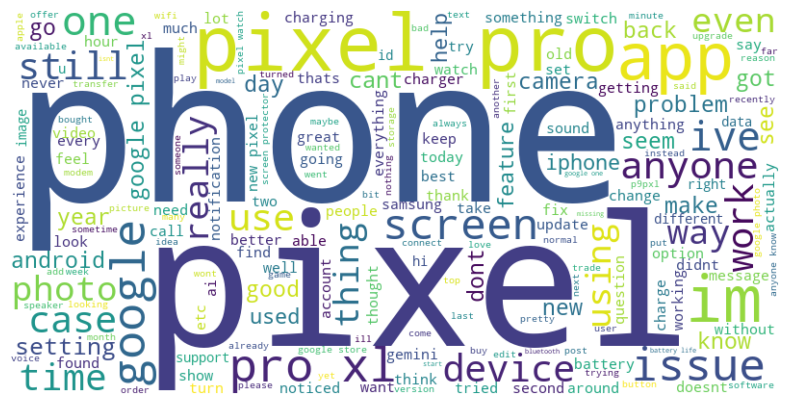

In [13]:
# Creating a word clous to visualize the most occuring words

text = ' '.join([token for l_token in reddit_tokens for token in l_token])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.show()

Some of the most occuring words in the word cloud is phone, pixel, pro. These words don't express much meaning because our subject is Google Pixel, a phone company. Therefore, we need to do some more cleaning, find bi-grams and remove most frequently occuring words and also the least frequently occuring words.

### N-grams

In [14]:
#  flattening the tokens into a single list
words = list(chain.from_iterable(reddit_tokens))
# Finding bigrams and trigrams
bigrams = list(ngrams(words, 2))
trigrams = list(ngrams(words, 3))

print(bigrams[0:9])
print('-'*40)
print(trigrams[0:9])

[('pixel', '9'), ('9', 'series'), ('series', 'shipping'), ('shipping', 'megathread'), ('megathread', 'september'), ('september', 'please'), ('please', 'post'), ('post', 'shipping'), ('shipping', 'related')]
----------------------------------------
[('pixel', '9', 'series'), ('9', 'series', 'shipping'), ('series', 'shipping', 'megathread'), ('shipping', 'megathread', 'september'), ('megathread', 'september', 'please'), ('september', 'please', 'post'), ('please', 'post', 'shipping'), ('post', 'shipping', 'related'), ('shipping', 'related', 'content')]


In [15]:
from collections import Counter
# Create a bigram and trigram data frame with frequency
bigrams_f = Counter(bigrams)
trigrams_f = Counter(trigrams)

bigram_df = pd.DataFrame(bigrams_f.items(), columns=['bigram', 'frequency']).sort_values(by='frequency', ascending=False, ignore_index= True)
trigram_df = pd.DataFrame(trigrams_f.items(), columns=['trigram', 'frequency']).sort_values(by='frequency', ascending=False, ignore_index= True)

In [16]:
bigram_df['bigram'] = bigram_df['bigram'].apply(lambda x: '_'.join(x))
bigram_df.head(15)

,bigram,frequency
0,pixel_9,551
1,9_pro,427
2,pro_xl,303
3,pixel_8,160
4,google_pixel,121
5,pixel_7,110
6,8_pro,108
7,7_pro,91
8,anyone_else,84
9,pixel_6,68


In [17]:
trigram_df['trigram'] = trigram_df['trigram'].apply(lambda x: '_'.join(x))
trigram_df.head(15)

,trigram,frequency
0,pixel_9_pro,324
1,9_pro_xl,290
2,pixel_8_pro,67
3,pixel_7_pro,65
4,google_pixel_9,43
5,anyone_else_issue,21
6,pixel_6_pro,21
7,new_pixel_9,20
8,pixel_9_series,18
9,got_pixel_9,16


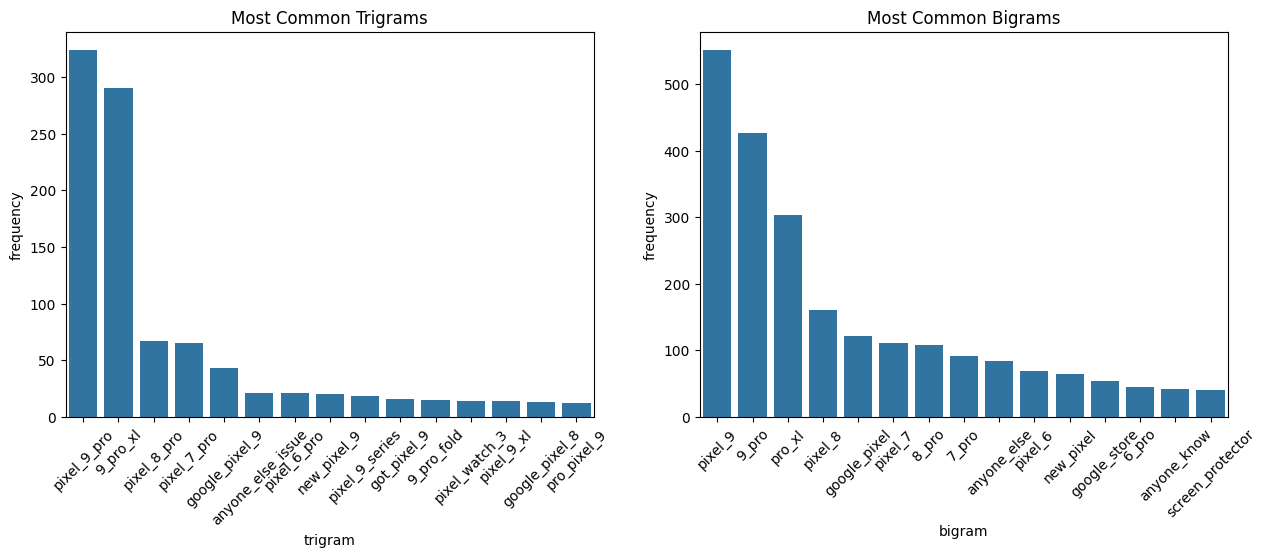

In [18]:
# Plot frequency distribution of trigrams
# plt.figure(figsize=(10, 5))
fig, axs = plt.subplots(nrows=1,ncols=2, figsize =(15,5))
sns.barplot(x='trigram', y='frequency', data=trigram_df.head(15), ax=axs[0])
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_title('Most Common Trigrams')
sns.barplot(x='bigram', y='frequency', data=bigram_df.head(15), ax=axs[1])
axs[1].tick_params(axis='x', rotation=45)
axs[1].set_title('Most Common Bigrams')
plt.show()

From the two plots we can see very skewed graphs. This means some words appear together more often than others. There is some overlap between the bigrams and trigram words, such as pixel 9, 9 pro overlaps with pixel 9 pro. Given the domain knowledge about google pixel, the top 5 trigrams are more relevant.

### Filtering by frequency

Before we remove any word, we are going to take a look at the frequency of words. The ideas is to remove the word that occur only once in the corpus and also the word that appear too frequently. These words makes our data noisy as they do not express much meaning.

In [19]:
# defining a function to find vocabulary
# we can use this to generate vocabulary after each preprocessing step
def vocab_finder(tokenized_list):
    words = list(chain.from_iterable(tokenized_list))
    # vocabulary of all words
    return sorted(list(set(words)))

In [20]:
# Number of unique words in our corpus
len(vocab_finder(reddit_tokens))

6164

In [21]:
# Finding the frequency distribution of words
words = list(chain.from_iterable(reddit_tokens))
word_fd = FreqDist(words)

In [22]:
# Words that appear once
word_once=set(word_fd.hapaxes())

In [23]:
# defining a filter that takes a token and a list of words as input
# it filters words from the token based on the filter list
def word_filter(tokens, filter_list):
    return [w for w in tokens if w not in filter_list]

In [24]:
clean_tokens =[word_filter(tk, word_once) for tk in reddit_tokens]
len(vocab_finder(clean_tokens))

3270

In [25]:
# Looking at the 20 most frequent words and their frequency
word_fd.most_common(20)

[('pixel', 1548),
 ('phone', 836),
 ('pro', 793),
 ('9', 734),
 ('google', 704),
 ('im', 480),
 ('xl', 389),
 ('like', 369),
 ('screen', 354),
 ('get', 314),
 ('issue', 303),
 ('ive', 298),
 ('app', 288),
 ('one', 279),
 ('anyone', 268),
 ('8', 237),
 ('work', 234),
 ('new', 228),
 ('device', 224),
 ('would', 224)]

We will remove the 5 most common words because there is a shrap drop of word frequency after the 5th word. After the 5th word the decline is much more gradual.

In [26]:
# putting the words we want to remove in a list to filter from
most_common = [word for word,freq in word_fd.most_common(5)]
most_common

['pixel', 'phone', 'pro', '9', 'google']

In [27]:
# Filtering the common words
clean_tokens =[word_filter(tk, most_common) for tk in clean_tokens]

From most common we can see that we need to remove some other words like im, ive. These were not removed by stopwords because it is not in standard english spelling format.

In [28]:
# List of words to filter out
filter_tokens = ['im', 'ive', 'dont']
clean_tokens =[word_filter(tk, filter_tokens) for tk in clean_tokens]

In [29]:
# Finding the frequency distribution of words
words = list(chain.from_iterable(clean_tokens))
word_fd = FreqDist(words)
word_fd.most_common(20)

[('xl', 389),
 ('like', 369),
 ('screen', 354),
 ('get', 314),
 ('issue', 303),
 ('app', 288),
 ('one', 279),
 ('anyone', 268),
 ('8', 237),
 ('work', 234),
 ('new', 228),
 ('device', 224),
 ('would', 224),
 ('time', 214),
 ('know', 212),
 ('use', 210),
 ('case', 206),
 ('photo', 204),
 ('camera', 189),
 ('using', 181)]

In [30]:
# Add the clean tokens to the data frame
df['Clean_tokens'] = clean_tokens
df.head()

,Title,Description,Post_time,Score,Comment_count,Full_Post,Tokens,Clean_tokens
0,pixel 9 series shipping megathread september,please post all shipping related content here,2024-09-01 23:26:08,20,154,pixel 9 series shipping megathread september ...,"[pixel, 9, series, shipping, megathread, septe...","[series, shipping, megathread, september, plea..."
1,flossy carter google pixel 9 pro xl real review,NaN,2024-09-03 11:37:51,64,54,flossy carter google pixel 9 pro xl real rev...,"[flossy, carter, google, pixel, 9, pro, xl, re...","[flossy, carter, xl, real, review]"
2,how have i never noticed this brilliant pixel ...,im not new to google phones as ive been using ...,2024-09-03 04:57:48,205,77,how have i never noticed this brilliant pixel ...,"[never, noticed, brilliant, pixel, camera, fea...","[never, noticed, brilliant, camera, feature, n..."
3,fingerprint sensor on the 9 series is actually...,i was worried about this before buying it but ...,2024-09-03 07:07:33,88,55,fingerprint sensor on the 9 series is actually...,"[fingerprint, sensor, 9, series, actually, rea...","[fingerprint, sensor, series, actually, really..."
4,yall try the add me feat with yourself,,2024-09-03 07:58:48,30,14,yall try the add me feat with yourself,"[yall, try, add, feat]","[yall, try, add]"


I deliberately chose not to remove other commonly occuring words at the moment. Google pixel is a phone company. Some of the frequently occuring words relate to its new models. It may not to beneficial discard these words simply based on frequency at this moment. Now I have a clean list of tokens ready for sentiment analysis and topic modelling.

### Sentiment Analysis

In [31]:
# Use vader model for sentiment analysis
sentiment = SentimentIntensityAnalyzer()

In [32]:
# Save thw compound sentiment score in list
sentiment_score=[]
for tokens in clean_tokens:
    sent_score = sentiment.polarity_scores(" ".join(tokens))
    sentiment_score.append(sent_score['compound'])

In [33]:
# Add the list to the data frame
df['Sentiment_score']=sentiment_score
df.head(10)

,Title,Description,Post_time,Score,Comment_count,Full_Post,Tokens,Clean_tokens,Sentiment_score
0,pixel 9 series shipping megathread september,please post all shipping related content here,2024-09-01 23:26:08,20,154,pixel 9 series shipping megathread september ...,"[pixel, 9, series, shipping, megathread, septe...","[series, shipping, megathread, september, plea...",0.3182
1,flossy carter google pixel 9 pro xl real review,NaN,2024-09-03 11:37:51,64,54,flossy carter google pixel 9 pro xl real rev...,"[flossy, carter, google, pixel, 9, pro, xl, re...","[flossy, carter, xl, real, review]",0.0000
2,how have i never noticed this brilliant pixel ...,im not new to google phones as ive been using ...,2024-09-03 04:57:48,205,77,how have i never noticed this brilliant pixel ...,"[never, noticed, brilliant, pixel, camera, fea...","[never, noticed, brilliant, camera, feature, n...",0.2565
3,fingerprint sensor on the 9 series is actually...,i was worried about this before buying it but ...,2024-09-03 07:07:33,88,55,fingerprint sensor on the 9 series is actually...,"[fingerprint, sensor, 9, series, actually, rea...","[fingerprint, sensor, series, actually, really...",0.8725
4,yall try the add me feat with yourself,,2024-09-03 07:58:48,30,14,yall try the add me feat with yourself,"[yall, try, add, feat]","[yall, try, add]",0.0000
5,my 2 cents,9 pro xl this phone is so good that its actua...,2024-09-03 01:05:11,106,44,my 2 cents 9 pro xl this phone is so good tha...,"[2, cents, 9, pro, xl, phone, good, actually, ...","[2, cent, xl, good, actually, boring, xd, hone...",0.8126
6,the google find my device network seems to be ...,purely anecdotal experience of course since we...,2024-09-03 01:25:05,48,11,the google find my device network seems to be ...,"[google, find, device, network, seems, getting...","[find, device, network, seems, getting, better...",0.6815
7,zoom enhance is the worst feature shipped by g...,i was so excited for this feature finally some...,2024-09-02 18:01:12,166,103,zoom enhance is the worst feature shipped by g...,"[zoom, enhance, worst, feature, shipped, googl...","[zoom, enhance, worst, feature, shipped, possi...",-0.9393
8,preferred texting apps,hello a friend of mine has a google pixel and ...,2024-09-03 09:29:49,10,18,preferred texting apps hello a friend of mine ...,"[preferred, texting, apps, hello, friend, mine...","[preferred, texting, apps, hello, friend, mine...",0.3818
9,pixel 9 pro xl all pro everything but,to caveat this post huge pixel fan and have ow...,2024-09-02 21:05:19,77,138,pixel 9 pro xl all pro everything but to cave...,"[pixel, 9, pro, xl, pro, everything, caveat, p...","[xl, everything, caveat, post, huge, fan, owne...",0.9911


In [34]:
df['Post_time'] = pd.to_datetime(df['Post_time'], errors='coerce')
# Make a data frame for sentiment analysis and visuals
sa_df = pd.DataFrame()

sa_df['Date'] = df['Post_time'].dt.date
sa_df['Hour'] = df['Post_time'].dt.hour
sa_df['Day'] = df['Post_time'].dt.day_name()
sa_df['Month'] = df['Post_time'].dt.month
sa_df['Sentiment'] = df['Sentiment_score']
sa_df['Reddit_score'] = df['Score']

In [35]:
# Create a column for sentiment label
# x>o positive, x<0 negative, x=0 neutral
sa_df['Sentiment_label'] = sa_df['Sentiment'].apply(lambda x: 'Positive' if x>0 else ('Negative' if x < 0 else 'Neutral'))

In [36]:
# Define the order for the days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert 'Day' column to categorical with the defined order
sa_df['Day'] = pd.Categorical(sa_df['Day'], categories=day_order, ordered=True)

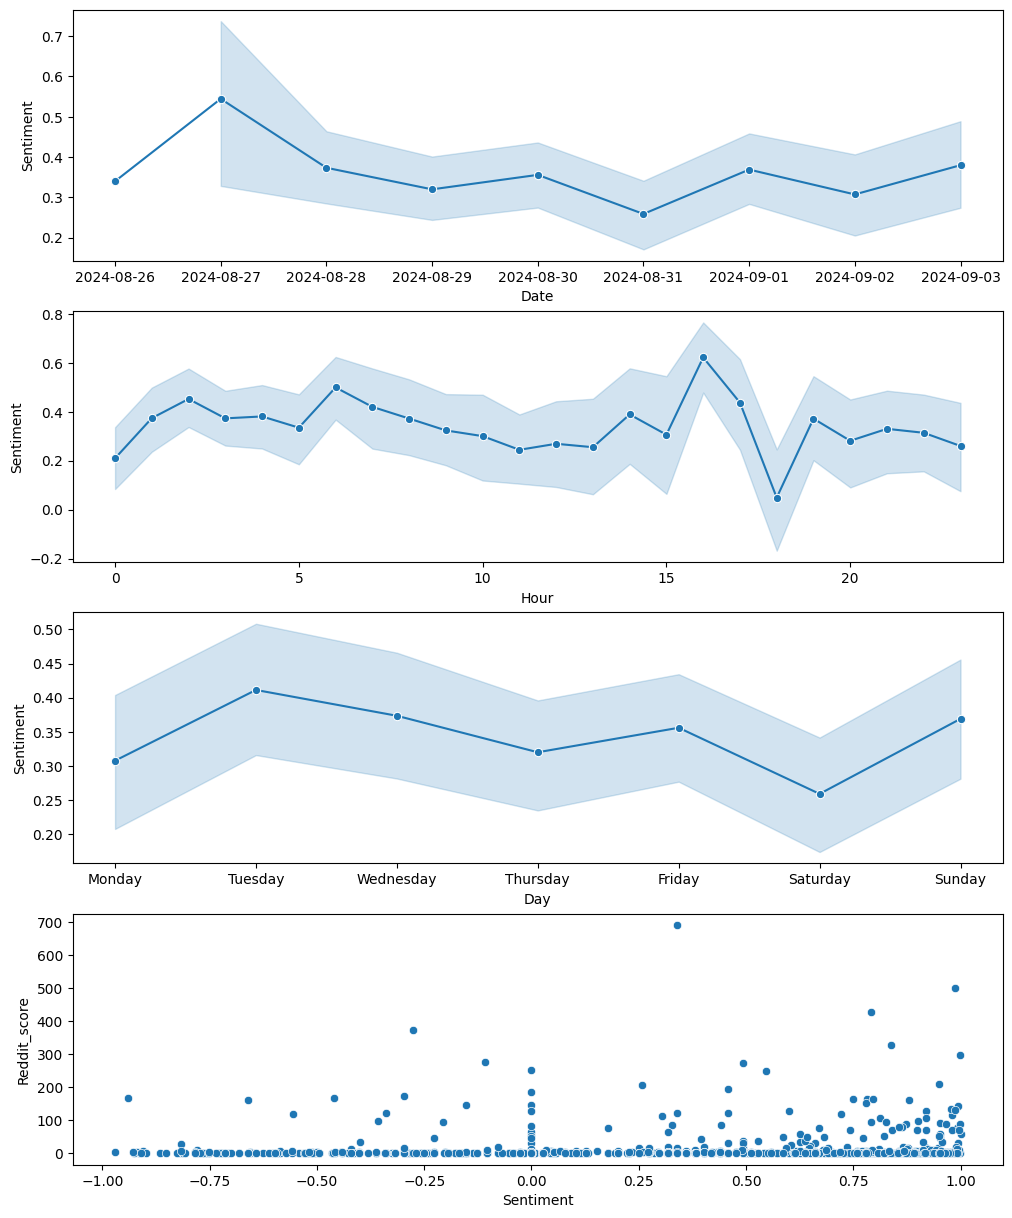

In [37]:
# Plot sentiment scores by date, hour and day
# Plot sentiment score by reddit score
fig, axs = plt.subplots(nrows=4,ncols=1, figsize =(12,15))

sns.lineplot(data=sa_df, x='Date', y='Sentiment', marker='o', ax=axs[0])
sns.lineplot(data=sa_df, x='Hour', y='Sentiment', marker='o', ax=axs[1])
sns.lineplot(data=sa_df, x='Day', y='Sentiment', marker='o', ax=axs[2])
sns.scatterplot(data=sa_df, x='Sentiment', y='Reddit_score',ax=axs[3])

plt.show()

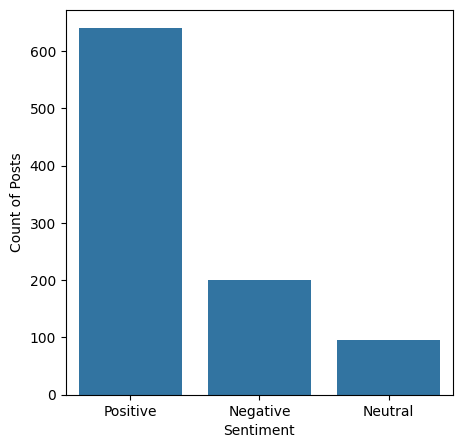

In [38]:
# Barplot of sentiment labels
sentiment_counts = sa_df['Sentiment_label'].value_counts()
plt.figure(figsize=(5, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)

plt.xlabel('Sentiment')
plt.ylabel('Count of Posts')
plt.show()

In [39]:
sentiment_counts

Sentiment_label
Positive    640
Negative    200
Neutral      96
Name: count, dtype: int64

From the plots we can see that there are more posts with positive sentiment compared to negative and neutral. The analysis of posts on different time units shows an interesting pattern. The data we extracted were posted between 26th August to 3rd September. The overall trend in this period shows a sharp peak of positive post on 27th August then a gradual decline, followed by a gradual rise. The plot against hours shows the posts made between 5pm and 6pm had a lot of negative sentiments.

Looking at the pattern of the sentiments over the days of week, we can see that sentiments scores peaked on Tuesday then gradually declined until Saturday, followed by another peak on Sunday. Finally, plotting reddit scores (based on upvotes and downvotes) we can see that positive posts in general tend to have higher score. 

### Topic Modelling

In [40]:
# Flattening the tokens to a list of strings
lPosts = [' '.join(token) for token in clean_tokens]

In [41]:
#
# LDA parameters
#

# number of topics to discover (default = 10)
topicNum = 6
# maximum number of words to display per topic (default = 10)
# Answer to Exercise 1 (change from 10 to 15)
wordNumToDisplay = 15
# this is the number of features/words to used to describe our documents
featureNum = 2000

In [42]:
#
# Count Vectorizer
#

tfVectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=featureNum, stop_words='english')
tf = tfVectorizer.fit_transform(lPosts)
# extract the names of the features (in our case, the words)
tfFeatureNames = tfVectorizer.get_feature_names_out()


#
# LDA MODEL
#

# Run LDA (see documentation about what the arguments means)
ldaModel = LatentDirichletAllocation(n_components =topicNum, max_iter=20, learning_method='online').fit(tf)

In [43]:
def display_topics(model, featureNames, numTopWords):
    """
    Prints out the most associated words for each feature.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    @param numTopWords: number of words to print per topic.
    """

    # print out the topic distributions
    for topicId, lTopicDist in enumerate(model.components_):
        print("Topic %d:" % (topicId))
        print(" ".join([featureNames[i] for i in lTopicDist.argsort()[:-numTopWords - 1:-1]]))

In [44]:
display_topics(ldaModel, tfFeatureNames, wordNumToDisplay)

Topic 0:
photo app message watch data device screen way new notification account transfer setting fold storage
Topic 1:
charging charger charge issue app weather bluetooth xl auto android connected connect battery new cable
Topic 2:
case xl like video p9p look sound color feel better time best camera audio 4a
Topic 3:
rcs model screenshots studio india available fb stand bubble europe sim sm regular teardown number
Topic 4:
store trade repair support offer credit buy year order available purchase told new best glass
Topic 5:
screen like xl issue camera use work know app time apps using thing really year


In [45]:
panel = pyLDAvis.lda_model.prepare(ldaModel, tf, tfVectorizer, mds='tsne')
pyLDAvis.display(panel)

In [46]:
def displayWordcloud(model, featureNames):
    """
    Displays the word cloud of the topic distributions, stored in model.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    """

    # this normalises each row/topic to sum to one
    # use this normalisedComponents to display your wordclouds
    normalisedComponents = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]

    
    topicNum = len(model.components_)
    # number of wordclouds for each row
    plotColNum = 2
    # number of wordclouds for each column
    plotRowNum = int(math.ceil(topicNum / plotColNum))
    plt.figure(figsize=(10, 3 * plotRowNum))

    for topicId, lTopicDist in enumerate(normalisedComponents):
        lWordProb = {featureNames[i] : wordProb for i,wordProb in enumerate(lTopicDist)}
        wordcloud = WordCloud(background_color='black')
        wordcloud.fit_words(frequencies=lWordProb)
        plt.subplot(plotRowNum, plotColNum, topicId+1)
        plt.title('Topic %d:' % (topicId+1))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")

    plt.show(block=True)

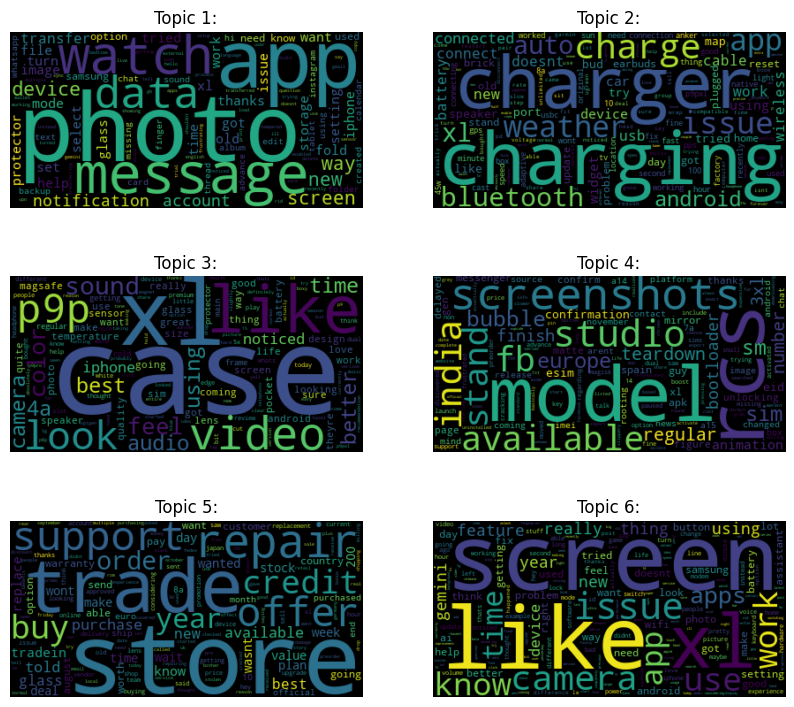

In [47]:
displayWordcloud(ldaModel, tfFeatureNames)

### Note to the marker

The outcome of topic modelling is different from the one that I have used to write the report. This is because the LDA moddel is effected by random seed. I was unaware of this at first. I learned about this when I compiled the code again before uploading. Therefore the wordcloud here may differ from the one in my report.

### References


Al-Serw, N. A.-R. (2021, February 19). Scraping Reddit using python Reddit API wrapper (PRAW). Analytics Vidhya. https://medium.com/analytics-vidhya/scraping-reddit-using-python-reddit-api-wrapper-praw-5c275e34a8f4

Hutto, C. J. (2014). vaderSentiment: VADER Sentiment Analysis. VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media, and works well on texts from other domains. https://github.com/cjhutto/vaderSentiment

PRAW 7.7.1 documentation. (n.d.). Readthedocs.Io. Retrieved September 6, 2024, from https://praw.readthedocs.io/en/stable/

Python. (2019, September 5). GeeksforGeeks. https://www.geeksforgeeks.org/python-textblob-correct-method/

RMIT. (2024). COSC2820 Advance programming for Data Science.

(N.d.). Datacamp.com. Retrieved September 6, 2024, from https://www.datacamp.com/tutorial/stemming-lemmatization-python